In [1]:
from collections.abc import MutableMapping

import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt

import superstats as sup
import bayesflow as bf

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:2026-05-05 14:09:09,427:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


## Specify Joint Prior

In [2]:
prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.15),
        ),
    a = sup.transition.RandomWalk(
        bounds=(0.0, 6.0),
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.15),
        delta=0.0
    ),
    bias = 0.5,
    tau = sup.transition.RandomWalk(
        bounds=(0.0, 6.0),
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.15),
        delta=0.0
    ),
)

## Specify Generative Model

In [3]:
generative_model = sup.simulation.GenerativeModel(
    prior=prior,
    model=sup.simulation.sample_ddm
)

In [4]:
print(generative_model.hyper_keys)
print(generative_model.local_keys)
print(generative_model.shared_keys)

['sigma_v', 'sigma_a', 'sigma_tau']
['v', 'a', 'tau']
[]


In [5]:
test_data = generative_model.sample(batch_size=50, steps=100, tile_to_steps=True)

In [6]:
train_data = generative_model.sample(batch_size=2000, steps=100, tile_to_steps=True)

In [8]:
for k, v in test_data.items():
    print(f"{k}: {v.shape}")

data: (50, 100, 2)
v: (50, 100, 1)
a: (50, 100, 1)
tau: (50, 100, 1)
sigma_v: (50, 100, 1)
sigma_a: (50, 100, 1)
sigma_tau: (50, 100, 1)


In [9]:
sim_data = generative_model.sample(batch_size=1000, steps=100, tile_to_steps=True)

In [10]:
local_keys = generative_model.local_keys
hyper_keys = generative_model.hyper_keys
shared_keys = generative_model.shared_keys

adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate(local_keys + hyper_keys + shared_keys, into="inference_variables")
    .rename("data", "summary_variables")
)

In [28]:
workflow = bf.BasicWorkflow(
    adapter=adapter,
    inference_network=bf.networks.StableConsistencyModel(subnet_kwargs={"widths": (128,)*3}),
    summary_network=sup.networks.RecurrentNet(recurrent_type="gru", hidden_dim=128),
    standardize="all"
)

In [ ]:
history = workflow.fit_offline(
    train_data, 
    batch_size=16, 
    epochs=50, 
    validation_data=test_data
)

In [30]:
new_data = generative_model.sample(1, steps=100)

samples = workflow.sample(conditions={"data": new_data["data"]}, num_samples=1000)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 6.89 seconds.


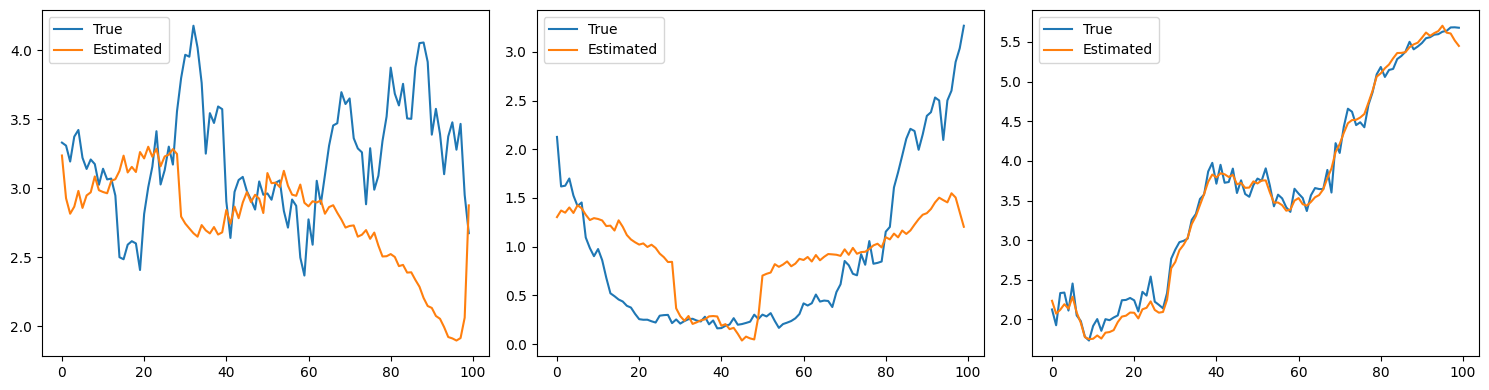

In [36]:
f, axarr = plt.subplots(1, 3, figsize=(15, 4))

for ax, key in zip(axarr.flat, generative_model.local_keys):
    ax.plot(new_data[key].squeeze(), label="True")
    ax.plot(samples[key].mean(1).squeeze(), label="Estimated")
    ax.legend()
f.tight_layout()

In [37]:
def aggregate(eta_samples, num_out=None, rng=None):
    """
    eta_samples: array of shape (S, T, P)
    returns: array of shape (num_out or S, P)
    """
    rng = np.random.default_rng(rng)
    B, S, T, P = eta_samples.shape

    if num_out is None:
        num_out = S

    pooled = eta_samples.reshape(B, S * T, P)
    idx = rng.choice(S * T, size=num_out, replace=True, axis=1)

    return pooled[:, idx, ...]

(array([ 20., 164., 344., 253., 129.,  55.,  24.,  10.,   0.,   1.]),
 array([-0.10304704, -0.03004427,  0.0429585 ,  0.11596127,  0.18896404,
         0.26196681,  0.33496958,  0.40797235,  0.48097512,  0.55397789,
         0.62698066]),
 <BarContainer object of 10 artists>)

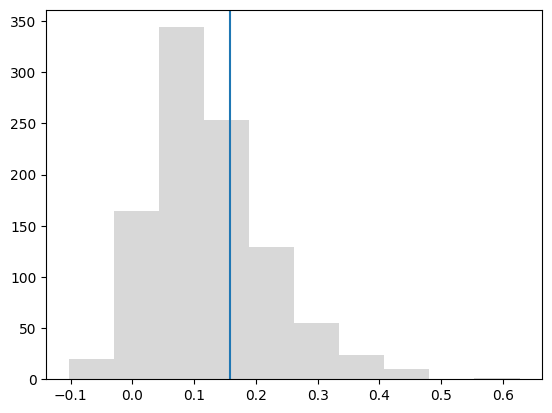

In [38]:
sigma_samples = aggregate(samples["sigma_v"])

plt.axvline(new_data["sigma_v"].squeeze())
plt.hist(sigma_samples.squeeze(), alpha=0.3, color="gray")